In [1]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

import pandas as pd

In [2]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

from collections import defaultdict
import numpy as np


def get_final_results(results, param="train_size", hyp_params=None, target="auc"):

    metric_idx = METRIC_INDEX[target]

    if hyp_params is None:
        hyp_params = []

    # =====================================================
    # 1️⃣ Collapse CV folds → group by full model identity
    # =====================================================
    by_model = defaultdict(list)

    for r in results:
        key = tuple([r[param]] + [r[h] for h in hyp_params])
        by_model[key].append(r)

    model_summary = []

    for key, group in by_model.items():
        p_val = key[0]
        hyp_vals = key[1:]  # all hyperparameters

        val_vals = [g["val_score"][metric_idx] for g in group]
        val_mean = np.nanmean(val_vals)

        test_val = group[0]["test_score"][metric_idx]

        model_summary.append(
            {
                "param": p_val,
                "hyp_vals": hyp_vals,
                "val_mean": val_mean,
                "test_metric": test_val,
                "model_dict": group[0],  # store original dict
            }
        )

    # =====================================================
    # 2️⃣ Select best model per param
    # =====================================================
    by_param = defaultdict(list)

    for row in model_summary:
        by_param[row["param"]].append(row)

    results_final = []
    best_models = {}

    for p_val, rows in by_param.items():

        val_scores = np.array([r["val_mean"] for r in rows])
        best_idx = np.nanargmax(val_scores)
        best = rows[best_idx]

        # results_final.append([p_val, best["test_metric"]])
        results_final.append([p_val, best["val_mean"]])

        # store best model info
        best_models[p_val] = {
            "val_mean": best["val_mean"],
            "test_metric": best["test_metric"],
            **{h: v for h, v in zip(hyp_params, best["hyp_vals"])},
        }
        # print out the best model info
        print(f"\nBest model for {param} = {p_val}")
        print("Validation mean:", best["val_mean"])
        print("Test metric:", best["test_metric"])
        print("Full model dict:")
        print(best["model_dict"])

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ Sort for plotting
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    return results_final.T

In [30]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_test_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ group by (train_size, xi) → average over CV
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        key = (r[param], r[hyp_param])
        by_combo[key].append(r)

    results_avg = []

    for (ts, xi), group in by_combo.items():
        # val_vals = [g["val_score"][metric_idx] for g in group]
        test_vals = [g["test_score"][metric_idx] for g in group]

        results_avg.append(
            [
                ts,  # train_size
                xi,  # xi
                # np.nanmean(val_vals),        # val metric
                np.nanmean(test_vals),  # test metric
            ]
        )

    results_avg = np.array(results_avg)
    # columns: [train_size, xi, val_metric, test_metric]

    # =====================================================
    # 2️⃣ group by train_size → select best xi
    # =====================================================
    by_train = defaultdict(list)

    for row in results_avg:
        by_train[row[0]].append(row)

    results_final = []

    for ts, rows in by_train.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 2])]
        results_final.append(best[[0, 2]])  # (train_size, test_metric)

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ sort for plotting + sanity check
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    assert len(np.unique(results_final[:, 0])) == results_final.shape[0]

    return results_final.T

## Case 1: separate

In [4]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/separate")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [5]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_bissgl_comb.gz']

In [6]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [7]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 5e-08,
   'tilde_lambda0': 100,
   'tilde_lambda1': 1,
   'lambda0': 100,
   'lambda1': 1,
   'K': 200,
   'cv': 0,
   'val_score': [0.008255489007900936,
    0.528514017086111,
    0.023310023310023312,
    0.906587894326162,
    0.14705882352941177,
    0.9123890823317983,
    0.012658227848101266],
   'val_d1': 2545,
   'val_d2': 1198,
   'val_d1_idx': array([   0,    1,    2, ..., 2543, 2544, 2545]),
   'val_d2_idx': array([   0,    1,    2, ..., 1203, 1204, 1205]),
   'test_score': [0.013269899633149056,
    0.5379800245164049,
    0.046242774566473986,
    0.9816074016274663,
    0.043478260869565216,
    0.9913278522356122,
    0.04938271604938271],
   'test_d1': 2543,
   'test_d2': 1198},
  {'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 5e-08,
   'tilde_lambda0': 100,
   'tilde_lambda1': 1,
   'lambda0': 100,
   'lambda1': 1,
   'K': 200,
   'cv': 1,
   'val_score': [0.01657860722786158,
    0.53640933

In [12]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["combo_idx"],
    target="auc",
)


Best model for train_size = 0.1
Validation mean: 0.5515846564857564
Test metric: 0.5516564487775258
Full model dict:
{'combo_idx': 9, 'train_size': 0.1, 'xi': 1, 'eta': 1e-08, 'tilde_lambda0': 100, 'tilde_lambda1': 1, 'lambda0': 100, 'lambda1': 1, 'K': 200, 'cv': 0, 'val_score': [0.011332739754471181, 0.5619985783243061, 0.04897959183673469, 0.9740274216921191, 0.08108108108108109, 0.9814544228391593, 0.03508771929824561], 'val_d1': 2546, 'val_d2': 1206, 'val_d1_idx': array([   0,    1,    2, ..., 2543, 2544, 2545]), 'val_d2_idx': array([   0,    1,    2, ..., 1203, 1204, 1205]), 'test_score': [0.012246906845599103, 0.5516564487775258, 0.029197080291970802, 0.930814104707762, 0.10144927536231885, 0.9394075909449262, 0.01705237515225335], 'test_d1': 2546, 'test_d2': 1206}

Best model for train_size = 0.30000000000000004
Validation mean: 0.6224089984298713
Test metric: 0.592508282311898
Full model dict:
{'combo_idx': 53, 'train_size': 0.30000000000000004, 'xi': 100, 'eta': 1e-08, 'tilde

In [13]:
results_bissgl

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.55158466, 0.59372471, 0.622409  , 0.64902443, 0.66990878,
        0.69543595, 0.72044468, 0.75637259]])

### IMC

In [14]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_imc_comb.gz']

In [15]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [16]:
results

[[{'train_size': 0.1,
   'repeat': 0,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.09272573070642964,
    0.5466717735541794,
    0.08524590163934426,
    0.9792665254709619,
    0.10612244897959183,
    0.9872881355932204,
    0.07123287671232877]},
  {'train_size': 0.1,
   'repeat': 1,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.09173002327146991,
    0.5839910555492634,
    0.10163934426229508,
    0.9796380931148515,
    0.12653061224489795,
    0.9874756262186891,
    0.08493150684931507]},
  {'train_size': 0.1,
   'repeat': 2,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.04869742749882184,
    0.5207127398732104,
   

In [17]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results[0])
metric_cols = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

metrics_mat = np.vstack(
    [np.asarray(s, dtype=float).reshape(1, -1) for s in df["test_score"]]
)
df[metric_cols] = metrics_mat

summary = df.groupby("train_size")[metric_cols].agg(["mean", "std"])
print(summary)

                aupr                 auc                  f1            \
                mean       std      mean       std      mean       std   
train_size                                                               
0.1         0.103183  0.031841  0.589941  0.080705  0.112634  0.070087   
0.2         0.119479  0.046143  0.582265  0.067085  0.115520  0.070532   
0.3         0.128551  0.045800  0.580449  0.050486  0.123333  0.066088   
0.4         0.161266  0.039027  0.628212  0.063007  0.175029  0.057223   
0.5         0.167248  0.046949  0.619400  0.051943  0.181861  0.059463   
0.6         0.200979  0.103434  0.659802  0.108233  0.222459  0.121819   
0.7         0.256003  0.126973  0.734413  0.127011  0.296531  0.145213   
0.8         0.196387  0.074567  0.681969  0.115010  0.224571  0.100984   

            accuracy              recall           specificity            \
                mean       std      mean       std        mean       std   
train_size                       

In [18]:
results_imc = np.array([summary.index, summary["auc"]["mean"]])
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.58994057, 0.58226479, 0.58044908, 0.62821172, 0.61939988,
        0.65980237, 0.73441279, 0.68196915]])

In [ ]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["lamb"],
    target="auc",
)

### SGIMC

In [20]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_sgimc_comb.gz']

In [21]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [22]:
results

[[{'train_size': 0.1,
   'repeat': 0,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.13199720492390807,
    0.7496071114811607,
    0.21691973969631237,
    0.9865864080555865,
    0.20408163265306123,
    0.9937753112344383,
    0.23148148148148148]},
  {'train_size': 0.1,
   'repeat': 1,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.1777633697488626,
    0.5259386775559182,
    0.0208046121067803,
    0.7096941998290789,
    0.33877551020408164,
    0.7131018449077546,
    0.010731833462632531]},
  {'train_size': 0.1,
   'repeat': 2,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 26912,
   'test_score': [0.3165055005923982,
    0.5015007667983947,
    0.01804256572648943,
    0.009103407275294467,
    1.0,

In [23]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results[0])
metric_cols = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

metrics_mat = np.vstack(
    [np.asarray(s, dtype=float).reshape(1, -1) for s in df["test_score"]]
)
df[metric_cols] = metrics_mat

summary = df.groupby("train_size")[metric_cols].agg(["mean", "std"])
print(summary)

                aupr                 auc                  f1            \
                mean       std      mean       std      mean       std   
train_size                                                               
0.1         0.127381  0.074897  0.547186  0.076989  0.063185  0.069332   
0.2         0.145579  0.117396  0.553725  0.092629  0.076354  0.087191   
0.3         0.242360  0.121071  0.546119  0.080494  0.075681  0.089111   
0.4         0.212916  0.143013  0.585611  0.108824  0.106045  0.089352   
0.5         0.210935  0.141775  0.647209  0.151990  0.186729  0.176683   
0.6         0.241813  0.154302  0.684275  0.162516  0.228126  0.193093   
0.7         0.165531  0.135345  0.618461  0.122406  0.160899  0.164411   
0.8         0.287777  0.177490  0.630431  0.178129  0.185158  0.216733   

            accuracy              recall           specificity            \
                mean       std      mean       std        mean       std   
train_size                       

In [ ]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["combo_idx"],
    target="auc",
)

In [24]:
results_sgimc = np.array([summary.index, summary["auc"]["mean"]])
results_sgimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.54718622, 0.55372484, 0.54611896, 0.58561122, 0.64720854,
        0.68427514, 0.61846114, 0.63043147]])

### DRIMC

In [25]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_drimc.gz']

In [26]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [27]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005671498743792416,
    0.5116635977007958,
    0.019397651863195507,
    0.8572437112176272,
    0.16593886462882096,
    0.8631764353170439,
    0.010300894551368935],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005678995419160208,
    0.5117355214743605,
    0.019432773109243698,
    0.8612566417716345,
    0.1615720524017467,
    0.8672612801678908,
    0.010338083263481419],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.0056761503697964144,
    0.5117537683475173,
    0.01955085865257596,
    0.8621112473525805,
    0.1615720524017467,
    0.8681232199070604,
    0.010404949381327334],
   'test_d1': 658,
   'test_d2': 409},
  {'train

In [32]:
results_drimc = get_test_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [166]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51177864, 0.51177332, 0.51189541, 0.51180957, 0.51186939,
        0.51182356, 0.51186922, 0.51184738]])

In [ ]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

### NRLMF

In [33]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_nrlmf.gz']

In [34]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [35]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.009101192319451085,
    0.4738563837114267,
    0.027918781725888325,
    0.9715379184780589,
    0.044897959183673466,
    0.9800509974501275,
    0.020257826887661142],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.011252601909557904,
    0.47551288251913937,
    0.029023746701846966,
    0.9726526214097276,
    0.044897959183673466,
    0.9811759412029398,
    0.021442495126705652],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.5025426262174739,
    0.5020200775675502,
    0.01815958195901123,
    0.015605841043361945,
    1.0,
    0.00656217189140543,
    0.009162989004413195],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t':

In [45]:
results_nrlmf = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [46]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.5014547 , 0.50132181, 0.50605583, 0.50571866, 0.56565883,
        0.5430568 , 0.5399334 , 0.50828789]])

In [ ]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

---

### Plot figures

In [38]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

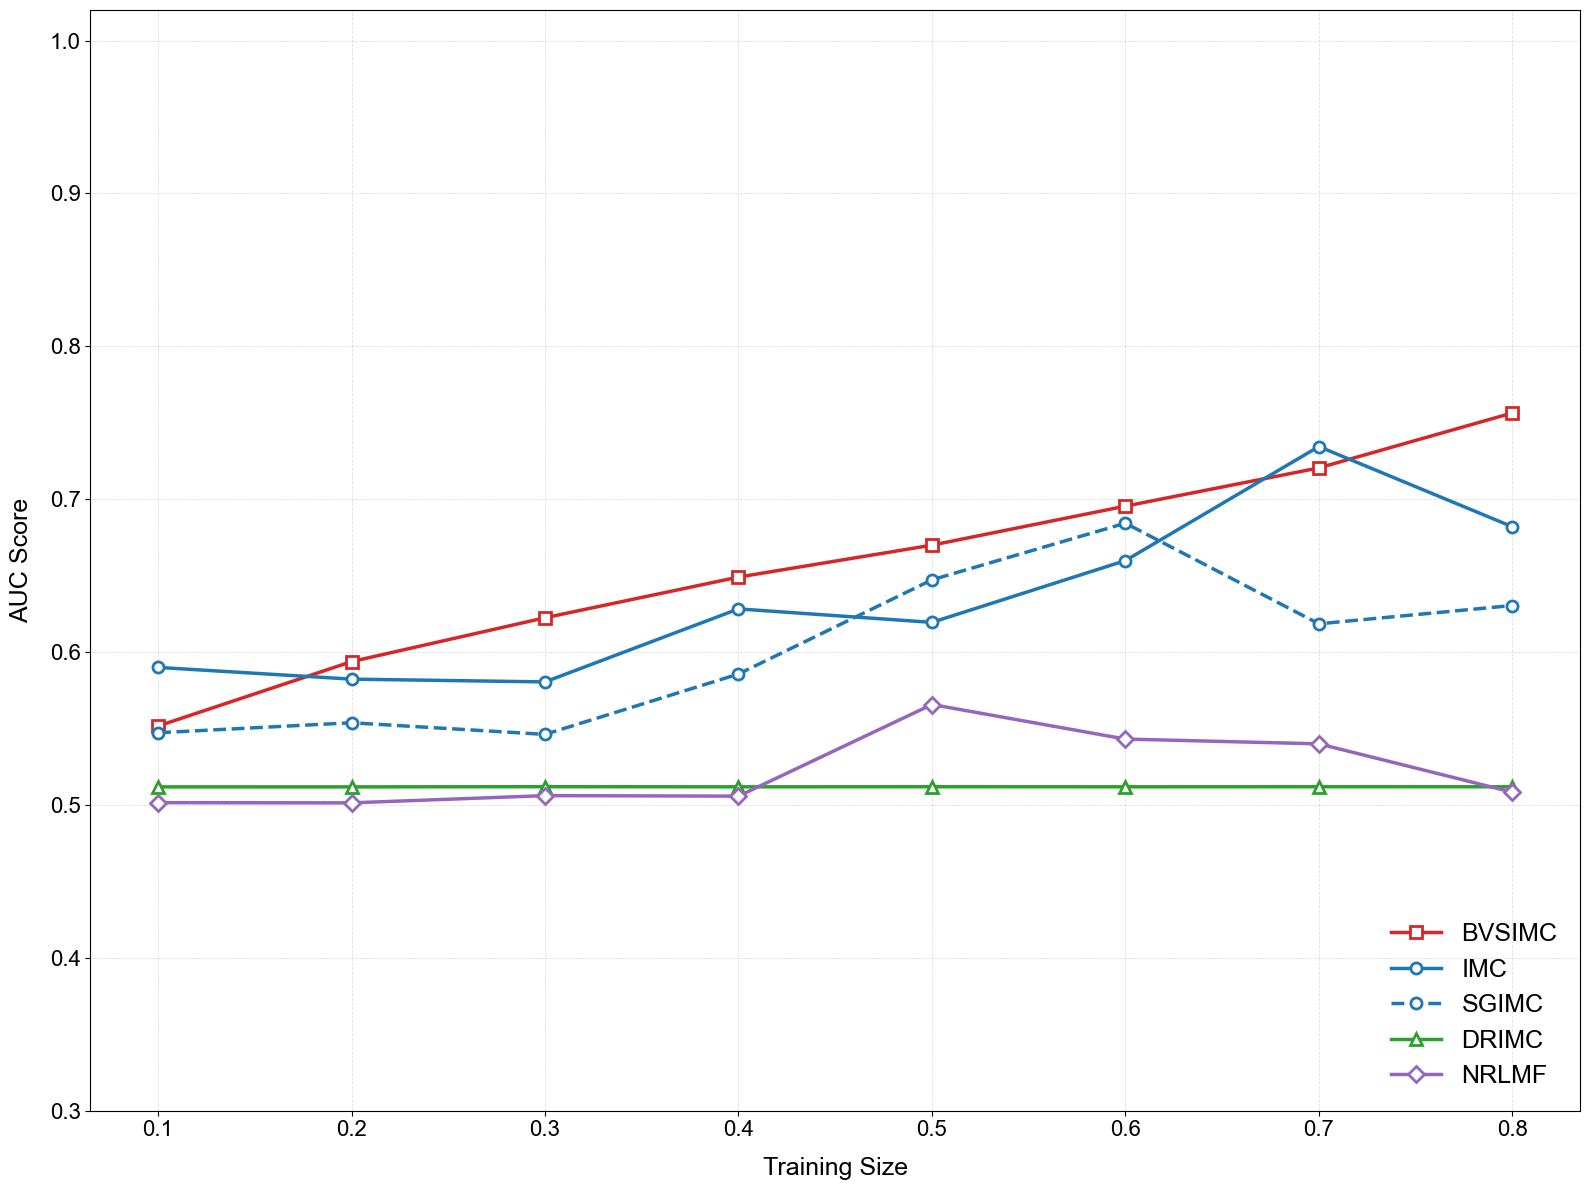

In [48]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BVSIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

# plt.plot(
#     results_drimc_identity[0],
#     results_drimc_identity[1],
#     label="DRIMC Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["DRIMC Identity"],
# )

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

# plt.plot(
#     results_nrlmf_identity[0],
#     results_nrlmf_identity[1],
#     label="NRLMF Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["NRLMF Identity"],
# )

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison_separate.pdf"),
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

---

## Case 2: noisy

In [49]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/noisy")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [50]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_bissgl_comb.gz']

In [51]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [52]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 1e-07,
   'tilde_lambda0': 100,
   'tilde_lambda1': 1,
   'lambda0': 100,
   'lambda1': 1,
   'K': 200,
   'cv': 0,
   'val_score': [0.009655692026810294,
    0.5547658904042145,
    0.03764705882352941,
    0.9240200631618057,
    0.21052631578947367,
    0.9290926099158092,
    0.020671834625323],
   'val_d1': 24,
   'val_d2': 132,
   'val_d1_idx': array([ 691,  738,  805, 1013, 1307, 1383, 1464, 1506, 1550, 1583, 1676,
          1746, 1747, 1753, 1758, 2251, 2252, 2305, 2424, 2426, 2430, 2438,
          2444, 2474]),
   'val_d2_idx': array([   5,    8,   22,   31,   45,   60,   64,   66,   83,   85,   99,
           106,  120,  134,  143,  159,  191,  209,  210,  211,  212,  222,
           227,  228,  232,  243,  250,  258,  260,  290,  294,  299,  300,
           309,  314,  315,  316,  320,  326,  327,  335,  337,  344,  345,
           348,  349,  350,  355,  356,  357,  358,  359,  360,  361,  362,
           365,  

In [53]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["combo_idx"],
    target="auc",
)


Best model for train_size = 0.1
Validation mean: 0.7021345139998656
Test metric: 0.6654171107748674
Full model dict:
{'combo_idx': 5, 'train_size': 0.1, 'xi': 20, 'eta': 1e-07, 'tilde_lambda0': 100, 'tilde_lambda1': 1, 'lambda0': 100, 'lambda1': 1, 'K': 200, 'cv': 0, 'val_score': [0.06007634191798997, 0.6750644329896908, 0.13245033112582782, 0.9756641278097715, 0.20833333333333334, 0.9825679475164011, 0.0970873786407767], 'val_d1': 378, 'val_d2': 308, 'val_d1_idx': array([  70,  143,  265,  658,  659,  661,  662,  667,  671,  673,  691,
        694,  703,  717,  722,  724,  729,  732,  738,  742,  748,  760,
        763,  772,  776,  777,  779,  780,  786,  788,  796,  798,  800,
        805,  809,  823,  833,  853,  855,  870,  874,  877,  880,  889,
        891,  893,  904,  908,  909,  915,  941,  942,  943,  952,  959,
        967,  991,  994,  995,  998,  999, 1002, 1013, 1017, 1018, 1023,
       1035, 1038, 1043, 1044, 1046, 1049, 1055, 1058, 1064, 1066, 1067,
       1080, 1083,

In [54]:
results[0]

[{'combo_idx': 0,
  'train_size': 0.1,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'cv': 0,
  'val_score': [0.009655692026810294,
   0.5547658904042145,
   0.03764705882352941,
   0.9240200631618057,
   0.21052631578947367,
   0.9290926099158092,
   0.020671834625323],
  'val_d1': 24,
  'val_d2': 132,
  'val_d1_idx': array([ 691,  738,  805, 1013, 1307, 1383, 1464, 1506, 1550, 1583, 1676,
         1746, 1747, 1753, 1758, 2251, 2252, 2305, 2424, 2426, 2430, 2438,
         2444, 2474]),
  'val_d2_idx': array([   5,    8,   22,   31,   45,   60,   64,   66,   83,   85,   99,
          106,  120,  134,  143,  159,  191,  209,  210,  211,  212,  222,
          227,  228,  232,  243,  250,  258,  260,  290,  294,  299,  300,
          309,  314,  315,  316,  320,  326,  327,  335,  337,  344,  345,
          348,  349,  350,  355,  356,  357,  358,  359,  360,  361,  362,
          365,  371,  372,  396,  402,  405,

In [55]:
results_bissgl

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.70213451, 0.77540656, 0.81208505, 0.83959268, 0.86329757,
        0.87470891, 0.88920849, 0.89724675]])

### IMC

In [56]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_imc_comb.gz']

In [57]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [58]:
results

[[{'train_size': 0.1,
   'repeat': 0,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.03691492288191249,
    0.7128053801391563,
    0.1027479091995221,
    0.9720952699438933,
    0.17551020408163265,
    0.9794135293235339,
    0.07263513513513513]},
  {'train_size': 0.1,
   'repeat': 1,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.07343368020111823,
    0.6822412705895318,
    0.14469453376205788,
    0.9802326013450748,
    0.1836734693877551,
    0.9875506224688766,
    0.11936339522546419]},
  {'train_size': 0.1,
   'repeat': 2,
   'rank': 50,
   'lamb': 0.0001,
   'C_lasso': 0.0,
   'C_group': 0.0,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.06212769993000853,
    0.6759161786808618,
  

In [59]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results[0])
metric_cols = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

metrics_mat = np.vstack(
    [np.asarray(s, dtype=float).reshape(1, -1) for s in df["test_score"]]
)
df[metric_cols] = metrics_mat

summary = df.groupby("train_size")[metric_cols].agg(["mean", "std"])
print(summary)

                aupr                 auc                  f1            \
                mean       std      mean       std      mean       std   
train_size                                                               
0.1         0.064701  0.028227  0.619606  0.086127  0.096306  0.050645   
0.2         0.079911  0.034178  0.696646  0.074187  0.134969  0.041473   
0.3         0.085036  0.027665  0.688947  0.095930  0.137489  0.043369   
0.4         0.104281  0.039122  0.691073  0.103766  0.149907  0.034908   
0.5         0.101031  0.028129  0.738609  0.080112  0.168931  0.028615   
0.6         0.115533  0.036644  0.712489  0.115564  0.173720  0.046055   
0.7         0.144179  0.036993  0.730128  0.107563  0.204459  0.042666   
0.8         0.147079  0.038144  0.740204  0.110410  0.211738  0.053041   

            accuracy              recall           specificity            \
                mean       std      mean       std        mean       std   
train_size                       

In [ ]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["lamb", "rank"],
    target="auc",
)

In [61]:
results_imc = np.array([summary.index, summary["auc"]["mean"]])
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.61960607, 0.69664584, 0.6889466 , 0.69107304, 0.73860926,
        0.71248895, 0.73012756, 0.74020381]])

### SGIMC

In [62]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc_comb.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_sgimc_comb.gz']

In [63]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [64]:
results

[[{'train_size': 0.1,
   'repeat': 0,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.07247879610652394,
    0.7147951530994878,
    0.15163934426229508,
    0.9846170995429718,
    0.1510204081632653,
    0.9922753862306884,
    0.1522633744855967]},
  {'train_size': 0.1,
   'repeat': 1,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.08228343490554228,
    0.6966168273218993,
    0.15126050420168066,
    0.9812358339835767,
    0.1836734693877551,
    0.9885630718464077,
    0.12857142857142856]},
  {'train_size': 0.1,
   'repeat': 2,
   'rank': 50,
   'C_lasso': 0.1,
   'C_group': 0.01,
   'C_ridge': 1.0,
   'splitter_seed': 3870553760,
   'n_train_obs': 269122,
   'test_score': [0.049484904672868806,
    0.5037802701701649,
    0.02142857142857143,
    0.9898190465574258,
    0.0

In [65]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results[0])
metric_cols = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

metrics_mat = np.vstack(
    [np.asarray(s, dtype=float).reshape(1, -1) for s in df["test_score"]]
)
df[metric_cols] = metrics_mat

summary = df.groupby("train_size")[metric_cols].agg(["mean", "std"])
print(summary)

                aupr                 auc                  f1            \
                mean       std      mean       std      mean       std   
train_size                                                               
0.1         0.074535  0.034429  0.630930  0.097499  0.093018  0.057867   
0.2         0.115809  0.026057  0.713571  0.106994  0.162547  0.065818   
0.3         0.151735  0.026963  0.749243  0.116998  0.204557  0.095722   
0.4         0.211758  0.090568  0.764126  0.137617  0.239545  0.106374   
0.5         0.242016  0.014162  0.854595  0.007902  0.316011  0.016131   
0.6         0.157017  0.114921  0.669523  0.177193  0.179841  0.156376   
0.7         0.276139  0.103349  0.814829  0.146848  0.314130  0.147640   
0.8         0.319687  0.101979  0.793033  0.174568  0.320331  0.166412   

            accuracy              recall           specificity            \
                mean       std      mean       std        mean       std   
train_size                       

In [184]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    # hyp_param="C_group",
    hyp_param=None,
    target="auc",
)

In [66]:
results_sgimc = np.array([summary.index, summary["auc"]["mean"]])
results_sgimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.63092999, 0.71357061, 0.74924261, 0.76412639, 0.854595  ,
        0.66952344, 0.81482894, 0.79303259]])

### DRIMC

In [67]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_drimc.gz']

In [68]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [69]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005671498743792416,
    0.5116635977007958,
    0.019397651863195507,
    0.8572437112176272,
    0.16593886462882096,
    0.8631764353170439,
    0.010300894551368935],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005678995419160208,
    0.5117355214743605,
    0.019432773109243698,
    0.8612566417716345,
    0.1615720524017467,
    0.8672612801678908,
    0.010338083263481419],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.0056761503697964144,
    0.5117537683475173,
    0.01955085865257596,
    0.8621112473525805,
    0.1615720524017467,
    0.8681232199070604,
    0.010404949381327334],
   'test_d1': 658,
   'test_d2': 409},
  {'train

In [70]:
results_drimc = get_test_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [71]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51177864, 0.51177332, 0.51189541, 0.51180957, 0.51186939,
        0.51182356, 0.51186922, 0.51184738]])

In [132]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.68814164, 0.7525281 , 0.78572343, 0.82288155, 0.86173826,
        0.87237384, 0.89609607, 0.91839774]])

### NRLMF

In [72]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_nrlmf.gz']

In [73]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [74]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.007389338186916924,
    0.5081525515560957,
    0.02753441802252816,
    0.9711291940697804,
    0.044897959183673466,
    0.9796385180740963,
    0.019855595667870037],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.02444216131698628,
    0.5170265976497093,
    0.0546448087431694,
    0.9871437595214209,
    0.04081632653061224,
    0.9958377081145943,
    0.08264462809917356],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.007832957541483372,
    0.5083617757887616,
    0.03379416282642089,
    0.9766283951993461,
    0.044897959183673466,
    0.9851882405879706,
    0.027093596059113302],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'l

In [75]:
results_nrlmf = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [76]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.5126956 , 0.51139756, 0.51189731, 0.5120108 , 0.51258368,
        0.5124079 , 0.51196504, 0.512433  ]])

In [138]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.65179307, 0.68783126, 0.76030349, 0.78811371, 0.82566152,
        0.85502697, 0.88057308, 0.89505327]])

---

### Plot figures

In [77]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

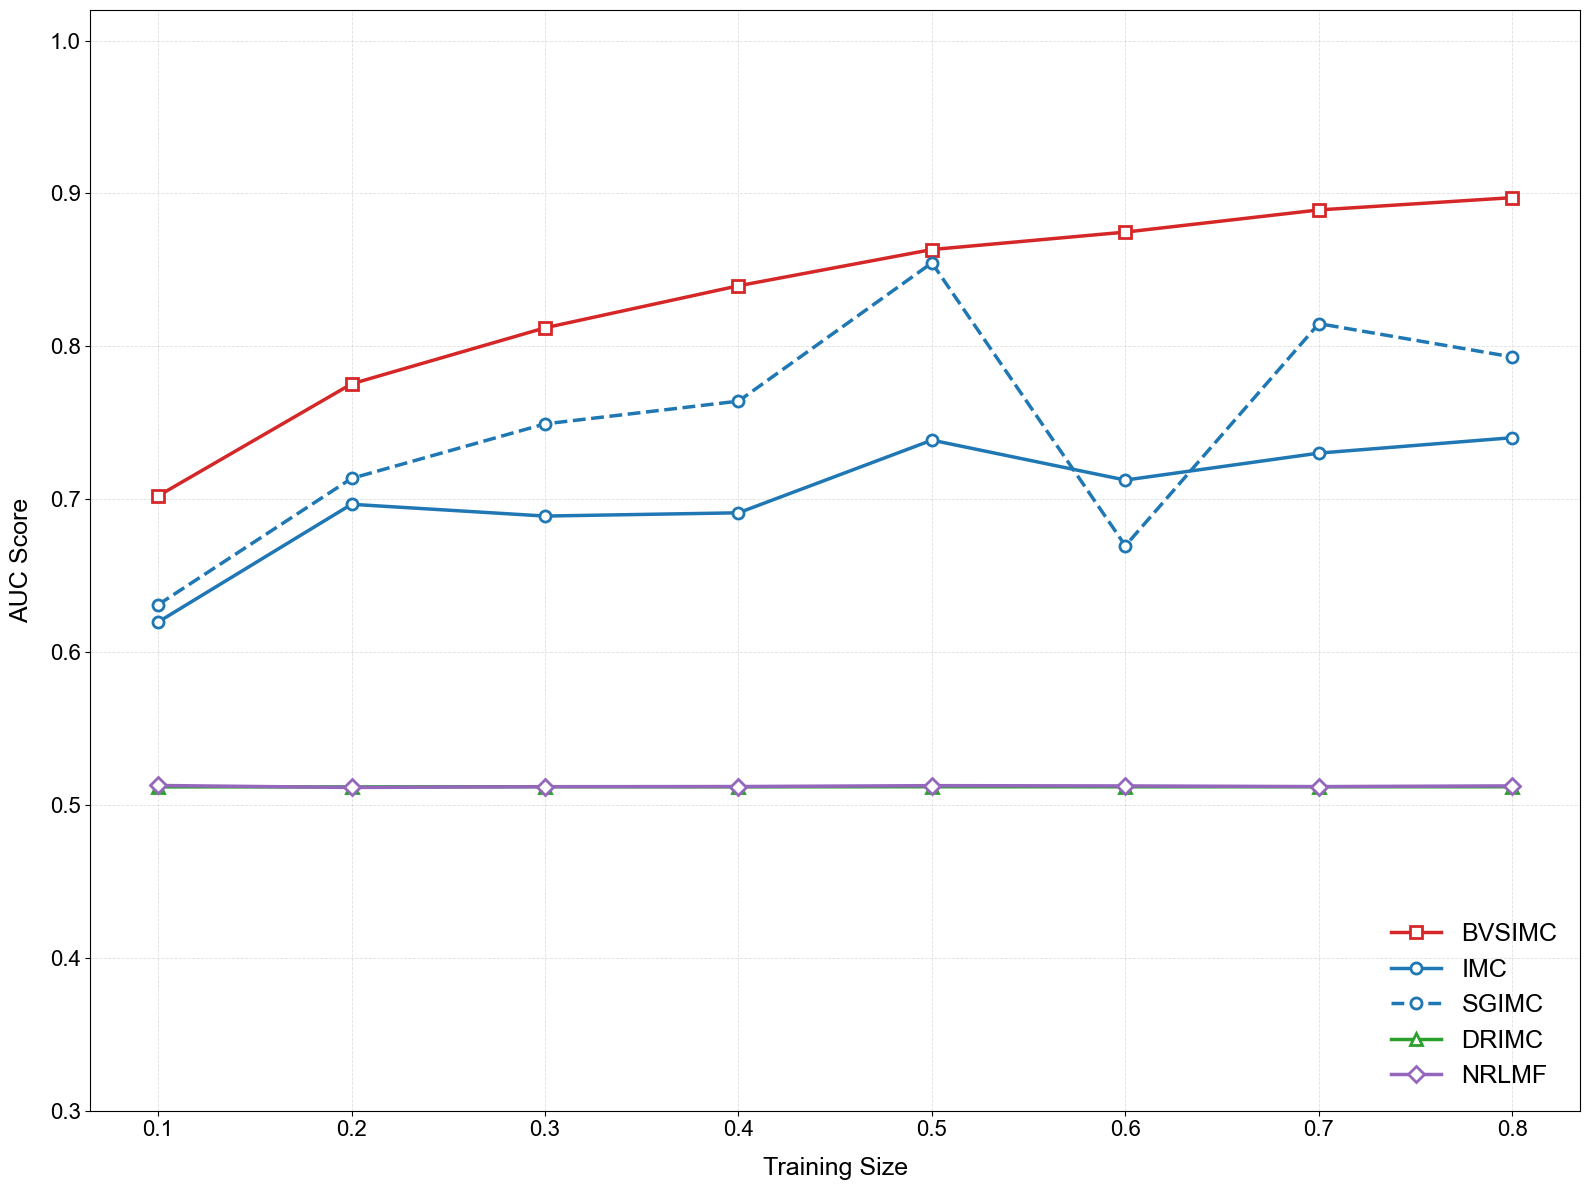

In [78]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BVSIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

# plt.plot(
#     results_drimc_identity[0],
#     results_drimc_identity[1],
#     label="DRIMC Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["DRIMC Identity"],
# )

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

# plt.plot(
#     results_nrlmf_identity[0],
#     results_nrlmf_identity[1],
#     label="NRLMF Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["NRLMF Identity"],
# )

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

#### Extra plots

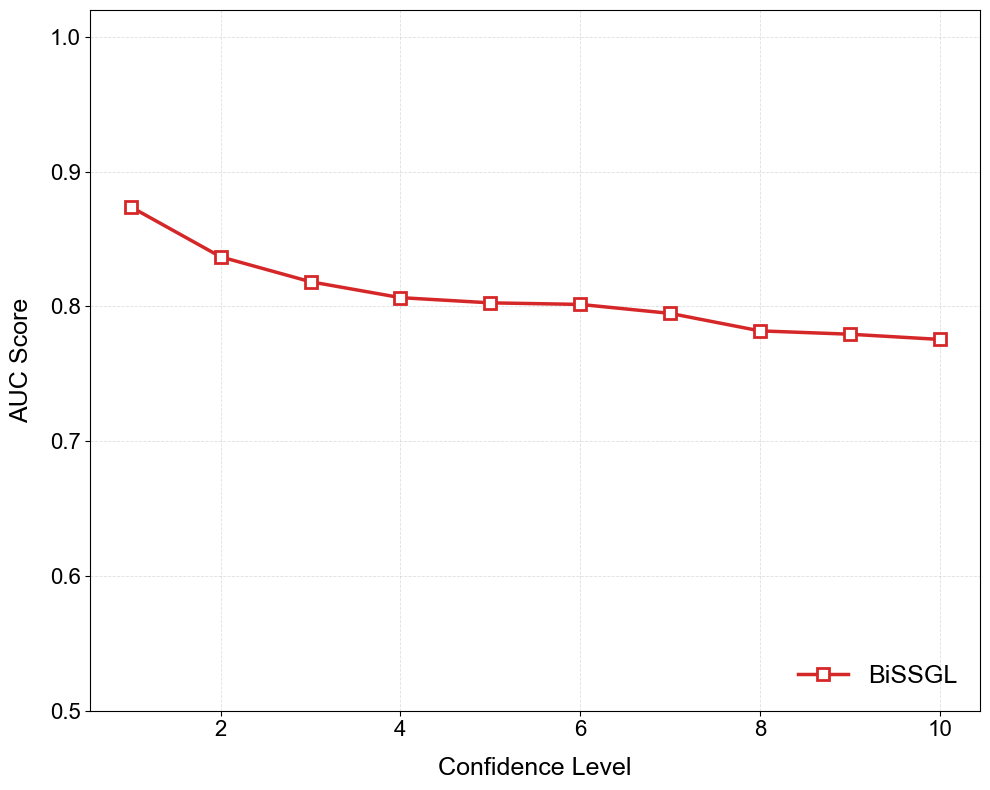

In [ ]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
# plt.plot(
#     results_bissgl_xi[0],
#     results_bissgl_xi[1],
#     label="BiSSGL",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["BiSSGL"],
# )

# Axis limits and labels
plt.ylim(0.5, 1.02)
plt.xlabel("Confidence Level", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_confidence_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

This is the BiSSGL in a random run with just identity matrix:

[{'train_size': 0.81,
  'xi': 10,
  'eta': 0.001,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.5976584761181942,
   **0.9209463761505803,**
   0.6160520607375272,
   0.9934232527031546,
   0.5795918367346938,
   0.9972251387430628,
   0.6574074074074074],
  'test_d1': 658,
  'test_d2': 409}]